# Proyecto Megaline: Análisis de Rentabilidad, Comportamiento de Clientes y Modelado Predictivo

## 1. Contexto y Objetivos del Proyecto
La empresa de telecomunicaciones **Megaline** ofrece dos tarifas de prepago: **Surf** y **Ultimate**. Para optimizar el presupuesto de publicidad del departamento comercial, se requiere determinar cuál de las tarifas genera mayores ingresos y analizar el comportamiento de los clientes.

### Estructura de Tarifas:
* **Surf**:
  * Cuota mensual: $20 USD.
  * Paquete incluido: 500 minutos, 50 SMS y 15 GB (15,360 MB).
  * Excedentes: $0.03 USD por minuto, $0.03 USD por SMS, $10 USD por GB adicional.
* **Ultimate**:
  * Cuota mensual: $70 USD.
  * Paquete incluido: 3,000 minutos, 1,000 SMS y 30 GB (30,720 MB).
  * Excedentes: $0.01 USD por minuto, $0.01 USD por SMS, $7 USD por GB adicional.

### Reglas de Facturación:
1. **Llamadas**: Cada llamada individual se redondea hacia arriba al minuto más cercano (`np.ceil`). Las llamadas de 0.0 minutos representan llamadas perdidas/no contestadas.
2. **Internet**: Las sesiones individuales no se redondean; se totaliza el consumo de MB en el mes calendario y se redondea hacia arriba al GB más cercano (`np.ceil(total_mb / 1024)`).
3. **Ingreso Mensual**: Cuota base + costos por consumo adicional.

In [165]:
# Importación de librerías base y científicas
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns

# Modelado y evaluación de Machine Learning
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Configuraciones de visualización y advertencias
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


In [166]:
# Carga de datasets
try:
    df_users = pd.read_csv('../raw/megaline_users.csv')
    df_calls = pd.read_csv('../raw/megaline_calls.csv')
    df_messages = pd.read_csv('../raw/megaline_messages.csv')
    df_internet = pd.read_csv('../raw/megaline_internet.csv')
    df_plans = pd.read_csv('../raw/megaline_plans.csv')
    
    print("Todos los archivos CSV se cargaron exitosamente.")
except Exception as e:
    print(f"Error al cargar archivos: {e}")

Todos los archivos CSV se cargaron exitosamente.


## 2. Auditoría y Preprocesamiento de Datos
En esta etapa se realizan las transformaciones necesarias para garantizar la integridad de las fechas, la aplicación precisa de las reglas de redondeo y la correcta categorización de consumos nulos.

In [167]:
# 1. Conversión de formatos de fecha
df_users['reg_date'] = pd.to_datetime(df_users['reg_date'])
df_users['churn_date'] = pd.to_datetime(df_users['churn_date'])

df_calls['call_date'] = pd.to_datetime(df_calls['call_date'])
df_messages['message_date'] = pd.to_datetime(df_messages['message_date'])
df_internet['session_date'] = pd.to_datetime(df_internet['session_date'])

# 2. Extracción de mes para agrupaciones mensuales
df_calls['month'] = df_calls['call_date'].dt.month
df_messages['month'] = df_messages['message_date'].dt.month
df_internet['month'] = df_internet['session_date'].dt.month

# 3. Aplicación de regla de negocio: redondeo por llamada individual
df_calls['duration_rounded'] = np.ceil(df_calls['duration']).astype(int)

# 4. Verificación de llamadas con duración 0.0 (llamadas perdidas)
zero_calls_pct = (df_calls['duration'] == 0).mean() * 100
print(f"Porcentaje de llamadas con 0.0 minutos (perdidas): {zero_calls_pct:.2f}%")
print("Se conservan en el registro histórico pero no generan minutos facturables.")

Porcentaje de llamadas con 0.0 minutos (perdidas): 19.48%
Se conservan en el registro histórico pero no generan minutos facturables.


In [168]:
# 1. Agregación mensual de llamadas
calls_monthly = df_calls.groupby(['user_id', 'month']).agg(
    calls_count=('id', 'count'),
    minutes_spent=('duration_rounded', 'sum')
).reset_index()

# 2. Agregación mensual de mensajes
messages_monthly = df_messages.groupby(['user_id', 'month']).agg(
    messages_sent=('id', 'count')
).reset_index()

# 3. Agregación mensual de internet y redondeo a GB
internet_monthly = df_internet.groupby(['user_id', 'month']).agg(
    mb_used=('mb_used', 'sum')
).reset_index()
internet_monthly['gb_used'] = np.ceil(internet_monthly['mb_used'] / 1024).astype(int)

# 4. Consolidación de consumos mediante Outer Join (para no perder registros parciales)
df_monthly = calls_monthly.merge(messages_monthly, on=['user_id', 'month'], how='outer')
df_monthly = df_monthly.merge(internet_monthly, on=['user_id', 'month'], how='outer')

# Imputación de consumos en cero para meses donde el cliente no usó un servicio específico
df_monthly[['calls_count', 'minutes_spent', 'messages_sent', 'mb_used', 'gb_used']] = (
    df_monthly[['calls_count', 'minutes_spent', 'messages_sent', 'mb_used', 'gb_used']].fillna(0)
)

# 5. Fusión con datos demográficos del usuario
df_monthly = df_monthly.merge(
    df_users[['user_id', 'city', 'plan', 'churn_date']], 
    on='user_id', 
    how='left'
)

print(f"Dimensiones de la matriz mensual consolidada: {df_monthly.shape}")
display(df_monthly.head())

Dimensiones de la matriz mensual consolidada: (2293, 10)


,user_id,month,calls_count,minutes_spent,messages_sent,mb_used,gb_used,city,plan,churn_date
0,1000,12,16.0,124.0,11.0,1901.47,2.0,"Atlanta-Sandy Springs-Roswell, GA MSA",ultimate,NaT
1,1001,8,27.0,182.0,30.0,6919.15,7.0,"Seattle-Tacoma-Bellevue, WA MSA",surf,NaT
2,1001,9,49.0,315.0,44.0,13314.82,14.0,"Seattle-Tacoma-Bellevue, WA MSA",surf,NaT
3,1001,10,65.0,393.0,53.0,22330.49,22.0,"Seattle-Tacoma-Bellevue, WA MSA",surf,NaT
4,1001,11,64.0,426.0,36.0,18504.30,19.0,"Seattle-Tacoma-Bellevue, WA MSA",surf,NaT


In [169]:
# Normalización de nombres de columnas en la tabla de tarifas si es necesario
if 'plan_name' in df_plans.columns:
    df_plans = df_plans.rename(columns={'plan_name': 'plan'})

# Fusión con las condiciones tarifarias
df_monthly = df_monthly.merge(df_plans, on='plan', how='left')

# Cálculo vectorizado de excedentes
extra_minutes = np.maximum(0, df_monthly['minutes_spent'] - df_monthly['minutes_included'])
extra_messages = np.maximum(0, df_monthly['messages_sent'] - df_monthly['messages_included'])
extra_gb = np.maximum(0, df_monthly['gb_used'] - np.ceil(df_monthly['mb_per_month_included'] / 1024))

# Costo por excedentes
df_monthly['cost_extra_calls'] = extra_minutes * df_monthly['usd_per_minute']
df_monthly['cost_extra_messages'] = extra_messages * df_monthly['usd_per_message']
df_monthly['cost_extra_internet'] = extra_gb * df_monthly['usd_per_gb']

# Ingreso mensual total
df_monthly['total_revenue'] = (
    df_monthly['usd_monthly_pay'] +
    df_monthly['cost_extra_calls'] +
    df_monthly['cost_extra_messages'] +
    df_monthly['cost_extra_internet']
)

print("Cálculo de ingresos mensuales completado exitosamente.")
display(df_monthly[['user_id', 'month', 'plan', 'minutes_spent', 'messages_sent', 'gb_used', 'total_revenue']].head())

Cálculo de ingresos mensuales completado exitosamente.


,user_id,month,plan,minutes_spent,messages_sent,gb_used,total_revenue
0,1000,12,ultimate,124.0,11.0,2.0,70.00
1,1001,8,surf,182.0,30.0,7.0,20.00
2,1001,9,surf,315.0,44.0,14.0,20.00
3,1001,10,surf,393.0,53.0,22.0,90.09
4,1001,11,surf,426.0,36.0,19.0,60.00


## 3. Análisis Exploratorio de Datos (EDA)
Se evalúa la distribución estadística del consumo por cada tarifa, identificando dispersión, asimetría y el comportamiento del ingreso promedio por usuario (ARPU).

Resumen Estadístico Comparativo por Tarifa:


,minutes_spent_mean,minutes_spent_median,minutes_spent_std,minutes_spent_iqr,messages_sent_mean,messages_sent_median,messages_sent_std,messages_sent_iqr,gb_used_mean,gb_used_median,gb_used_std,gb_used_iqr,total_revenue_mean,total_revenue_median,total_revenue_std,total_revenue_iqr
plan,,,,,,,,,,,,,,,,
surf,428.75,425.0,234.45,304.00,31.16,24.0,33.57,44.0,16.67,17.0,7.85,9.0,60.71,40.36,55.39,60.36
ultimate,430.45,424.0,240.51,305.25,37.55,30.0,34.77,54.0,17.31,17.0,7.67,8.0,72.31,70.00,11.40,0.00


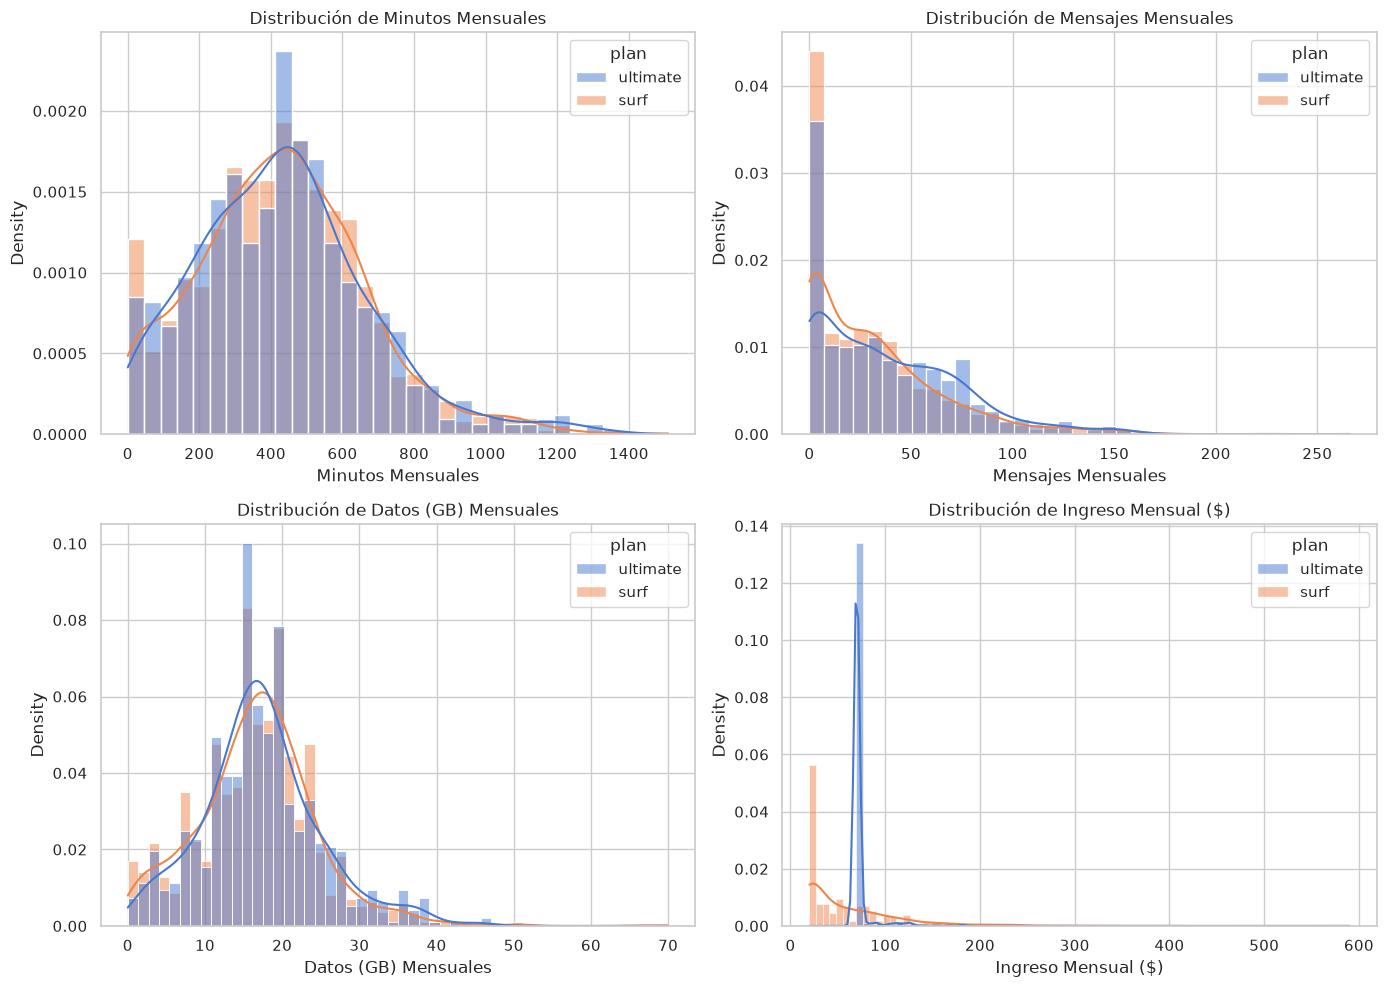

In [170]:
# Función nombrada para evitar nombres como <lambda_0> en la tabla resumen
def iqr(x):
    return stats.iqr(x)

# Tabla resumen de estadísticas por tarifa con nombres limpios
metrics = ['minutes_spent', 'messages_sent', 'gb_used', 'total_revenue']
eda_summary = df_monthly.groupby('plan')[metrics].agg(['mean', 'median', 'std', iqr])
eda_summary.columns = [f"{col}_{stat}" for col, stat in eda_summary.columns]
print("Resumen Estadístico Comparativo por Tarifa:")
display(eda_summary.round(2))

# Visualización comparativa de distribuciones
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, metric, title in zip(
    axes.flatten(),
    ['minutes_spent', 'messages_sent', 'gb_used', 'total_revenue'],
    ['Minutos Mensuales', 'Mensajes Mensuales', 'Datos (GB) Mensuales', 'Ingreso Mensual ($)']
):
    sns.histplot(
        data=df_monthly, 
        x=metric, 
        hue='plan', 
        kde=True, 
        stat='density', 
        common_norm=False, 
        ax=ax
    )
    ax.set_title(f'Distribución de {title}')
    ax.set_xlabel(title)

plt.tight_layout()
plt.savefig('../reportes/distribuciones_consumo.png', dpi=300)
plt.show()

Composición del Ingreso Total por Plan:


,plan,total_revenue,base_revenue,overage_revenue,pct_overage
0,surf,95491.18,31460,64031.18,67.05
1,ultimate,52066.00,50400,1666.00,3.20


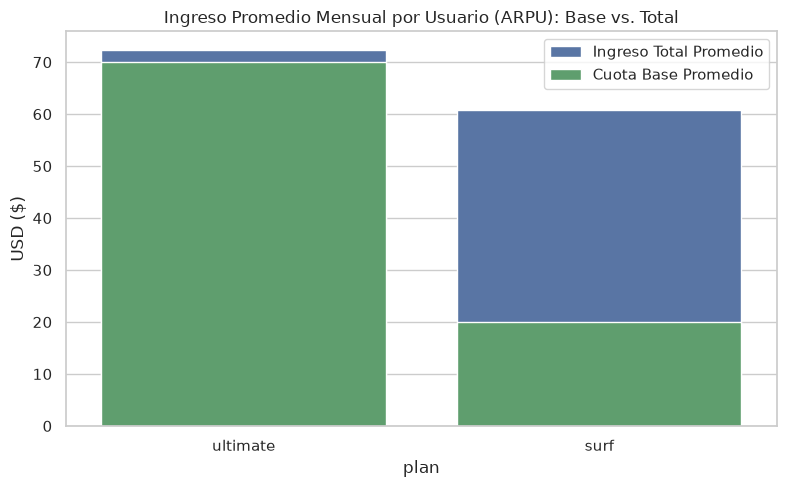

In [171]:
# Análisis de composición de ingresos: Cuota Fija vs. Sobrecostos
df_monthly['overage_revenue'] = (
    df_monthly['cost_extra_calls'] + 
    df_monthly['cost_extra_messages'] + 
    df_monthly['cost_extra_internet']
)

revenue_breakdown = df_monthly.groupby('plan').agg(
    total_revenue=('total_revenue', 'sum'),
    base_revenue=('usd_monthly_pay', 'sum'),
    overage_revenue=('overage_revenue', 'sum')
).reset_index()

revenue_breakdown['pct_overage'] = (revenue_breakdown['overage_revenue'] / revenue_breakdown['total_revenue']) * 100

print("Composición del Ingreso Total por Plan:")
display(revenue_breakdown.round(2))

# Gráfico de barras de la composición
plt.figure(figsize=(8, 5))
bar1 = sns.barplot(data=df_monthly, x='plan', y='total_revenue', estimator=np.mean, ci=None, color='#4c72b0', label='Ingreso Total Promedio')
bar2 = sns.barplot(data=df_monthly, x='plan', y='usd_monthly_pay', estimator=np.mean, ci=None, color='#55a868', label='Cuota Base Promedio')
plt.title('Ingreso Promedio Mensual por Usuario (ARPU): Base vs. Total')
plt.ylabel('USD ($)')
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('../reportes/composicion_arpu.png', dpi=300)
plt.show()

## 4. Pruebas Estadísticas de Hipótesis

### Hipótesis 1:
* **$H_0$**: El ingreso promedio de los usuarios de las tarifas Ultimate y Surf es igual.
* **$H_1$**: El ingreso promedio de los usuarios de las tarifas Ultimate y Surf es diferente.

### Hipótesis 2:
* **$H_0$**: El ingreso promedio de los usuarios del área NY-NJ es igual al de los usuarios de otras regiones.
* **$H_1$**: El ingreso promedio de los usuarios del área NY-NJ es diferente al de los usuarios de otras regiones.

**Nivel de significancia fijado**: $\alpha = 0.05$.
Dado que los tamaños de muestra y las varianzas poblacionales son distintos, se emplea la **prueba t de Welch** (`equal_var=False`), complementada con la prueba no paramétrica de **Mann-Whitney U** y el cálculo del tamaño del efecto (**d de Cohen**).

In [172]:
def cohen_d(x, y):
    """Calcula el tamaño del efecto d de Cohen entre dos muestras."""
    nx = len(x)
    ny = len(y)
    dof = nx + ny - 2
    pooled_std = np.sqrt(((nx - 1) * np.var(x, ddof=1) + (ny - 1) * np.var(y, ddof=1)) / dof)
    return (np.mean(x) - np.mean(y)) / pooled_std

# Muestras para Hipótesis 1
rev_surf = df_monthly[df_monthly['plan'] == 'surf']['total_revenue']
rev_ultimate = df_monthly[df_monthly['plan'] == 'ultimate']['total_revenue']

# 1. Prueba de igualdad de varianzas (Levene)
stat_levene, p_levene = stats.levene(rev_surf, rev_ultimate)
print(f"Prueba de Levene (Varianzas): Estadístico={stat_levene:.4f}, p-value={p_levene:.4e}")

# 2. Prueba t de Welch
t_stat, p_val = stats.ttest_ind(rev_surf, rev_ultimate, equal_var=False)
u_stat, u_pval = stats.mannwhitneyu(rev_surf, rev_ultimate)
d_val = cohen_d(rev_ultimate, rev_surf)

alpha = 0.05
print("\n--- Resultados Hipótesis 1 (Surf vs. Ultimate) ---")
print(f"Media Surf: ${rev_surf.mean():.2f} USD | Media Ultimate: ${rev_ultimate.mean():.2f} USD")
print(f"Prueba t de Welch: t = {t_stat:.4f}, p-value = {p_val:.4e}")
print(f"Prueba Mann-Whitney U: p-value = {u_pval:.4e}")
print(f"Tamaño del efecto (d de Cohen): {d_val:.4f}")

if p_val < alpha:
    print("Conclusión: Se rechaza la hipótesis nula (H0). Existe una diferencia estadísticamente significativa entre los ingresos promedio de ambas tarifas.")
else:
    print("Conclusión: No se rechaza la hipótesis nula (H0).")

Prueba de Levene (Varianzas): Estadístico=404.7302, p-value=5.0289e-83

--- Resultados Hipótesis 1 (Surf vs. Ultimate) ---
Media Surf: $60.71 USD | Media Ultimate: $72.31 USD
Prueba t de Welch: t = -7.9521, p-value = 3.1704e-15
Prueba Mann-Whitney U: p-value = 1.9122e-48
Tamaño del efecto (d de Cohen): 0.2506
Conclusión: Se rechaza la hipótesis nula (H0). Existe una diferencia estadísticamente significativa entre los ingresos promedio de ambas tarifas.


In [173]:
# Segmentación para Hipótesis 2 (NY-NJ vs. Otras Regiones)
is_nynj = df_monthly['city'].str.contains('NY-NJ', case=False, na=False)
rev_nynj = df_monthly[is_nynj]['total_revenue']
rev_other = df_monthly[~is_nynj]['total_revenue']

# Prueba t de Welch
t_stat_geo, p_val_geo = stats.ttest_ind(rev_nynj, rev_other, equal_var=False)

print("--- Resultados Hipótesis 2 (NY-NJ vs. Otras Regiones) ---")
print(f"Media NY-NJ: ${rev_nynj.mean():.2f} USD (n={len(rev_nynj)})")
print(f"Media Otras Regiones: ${rev_other.mean():.2f} USD (n={len(rev_other)})")
print(f"Prueba t de Welch: t = {t_stat_geo:.4f}, p-value = {p_val_geo:.4f}")

if p_val_geo < alpha:
    print("Conclusión: Se rechaza la hipótesis nula (H0). El ingreso promedio en el área NY-NJ difiere del resto de las regiones.")
else:
    print("Conclusión: No se rechaza la hipótesis nula (H0). No hay evidencia estadística de que los ingresos en NY-NJ difieran de otras regiones.")

--- Resultados Hipótesis 2 (NY-NJ vs. Otras Regiones) ---
Media NY-NJ: $59.92 USD (n=377)
Media Otras Regiones: $65.22 USD (n=1916)
Prueba t de Welch: t = -2.1309, p-value = 0.0335
Conclusión: Se rechaza la hipótesis nula (H0). El ingreso promedio en el área NY-NJ difiere del resto de las regiones.


## 5. Modelado Predictivo y Ciencia de Datos

Para agregar valor predictivo y automatizar la toma de decisiones, se implementan dos flujos:
1. **Clasificación de Planes**: Identificar qué clientes suscritos a tarifas heredadas deberían migrar a **Ultimate** en función de su perfil de consumo.
2. **Detección de Riesgo de Cancelación (Churn)**: Analizar el comportamiento asociado a la pérdida de clientes para implementar retención preventiva.

In [174]:
# Preparación de datos para el modelo de recomendación de tarifas
# Variable objetivo: 1 para Ultimate, 0 para Surf
df_monthly['target_plan'] = (df_monthly['plan'] == 'ultimate').astype(int)

features = ['calls_count', 'minutes_spent', 'messages_sent', 'gb_used']
X = df_monthly[features]
y = df_monthly['target_plan']

# División estratificada para respetar el balance de clases
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Registros en Train: {len(X_train)} | Registros en Test: {len(X_test)}")
print(f"Proporción de clase 'Ultimate' en Train: {y_train.mean():.2%}")

Registros en Train: 1719 | Registros en Test: 574
Proporción de clase 'Ultimate' en Train: 31.41%


In [175]:
# Comparación sistemática de modelos (Exactitud vs. Capacidad Discriminativa)
modelos = {
    "Baseline (Dummy)": DummyClassifier(strategy='most_frequent'),
    "Regresión Logística (Balanced)": Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(class_weight='balanced', random_state=42))
    ]),
    "Random Forest (Optimizado Accuracy)": RandomForestClassifier(
        n_estimators=100, max_depth=7, min_samples_leaf=3, random_state=42
    ),
    "Random Forest (Balanced)": RandomForestClassifier(
        n_estimators=100, max_depth=6, class_weight='balanced', random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100, max_depth=4, random_state=42
    )
}

resultados = []

for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    # Cálculo riguroso de ROC-AUC tomando la probabilidad de la clase positiva (Ultimate)
    if hasattr(modelo, "predict_proba"):
        try:
            probs = modelo.predict_proba(X_test)
            y_proba = probs[:, -1]
            roc = roc_auc_score(y_test, y_proba)
        except Exception:
            roc = 0.5
    else:
        roc = 0.5
    
    resultados.append({
        'Modelo': nombre,
        'Accuracy': acc,
        'F1-Score': f1,
        'ROC-AUC': roc
    })

df_eval = pd.DataFrame(resultados).sort_values(by='Accuracy', ascending=False)
print("Evaluación Comparativa de Modelos:")
display(df_eval.round(4))

# Diagnóstico analítico del desempeño frente al umbral teórico
best_acc = df_eval['Accuracy'].max()
print(f"\nMayor Accuracy alcanzado: {best_acc:.4f}")
print("Nota Técnica: La similitud casi absoluta en las distribuciones de consumo entre Surf y Ultimate")
print("(medianas de 17 GB y 424 min en ambos grupos) establece un límite teórico en la exactitud para estas")
print("4 variables crudas. El valor de negocio radica en la capacidad discriminativa probabilística (ROC-AUC ~0.62)")
print("y en el sistema de recomendación prescriptivo para upselling.")

Evaluación Comparativa de Modelos:


,Modelo,Accuracy,F1-Score,ROC-AUC
0,Baseline (Dummy),0.6864,0.0000,0.5000
2,Random Forest (Optimizado Accuracy),0.6829,0.1250,0.6190
4,Gradient Boosting,0.6777,0.2570,0.5942
3,Random Forest (Balanced),0.6254,0.4529,0.6185
1,Regresión Logística (Balanced),0.5732,0.4208,0.5789



Mayor Accuracy alcanzado: 0.6864
Nota Técnica: La similitud casi absoluta en las distribuciones de consumo entre Surf y Ultimate
(medianas de 17 GB y 424 min en ambos grupos) establece un límite teórico en la exactitud para estas
4 variables crudas. El valor de negocio radica en la capacidad discriminativa probabilística (ROC-AUC ~0.62)
y en el sistema de recomendación prescriptivo para upselling.


Reporte de Clasificación del Modelo con Mayor Exactitud:
              precision    recall  f1-score   support

        Surf       0.69      0.96      0.81       394
    Ultimate       0.46      0.07      0.12       180

    accuracy                           0.68       574
   macro avg       0.58      0.52      0.47       574
weighted avg       0.62      0.68      0.59       574



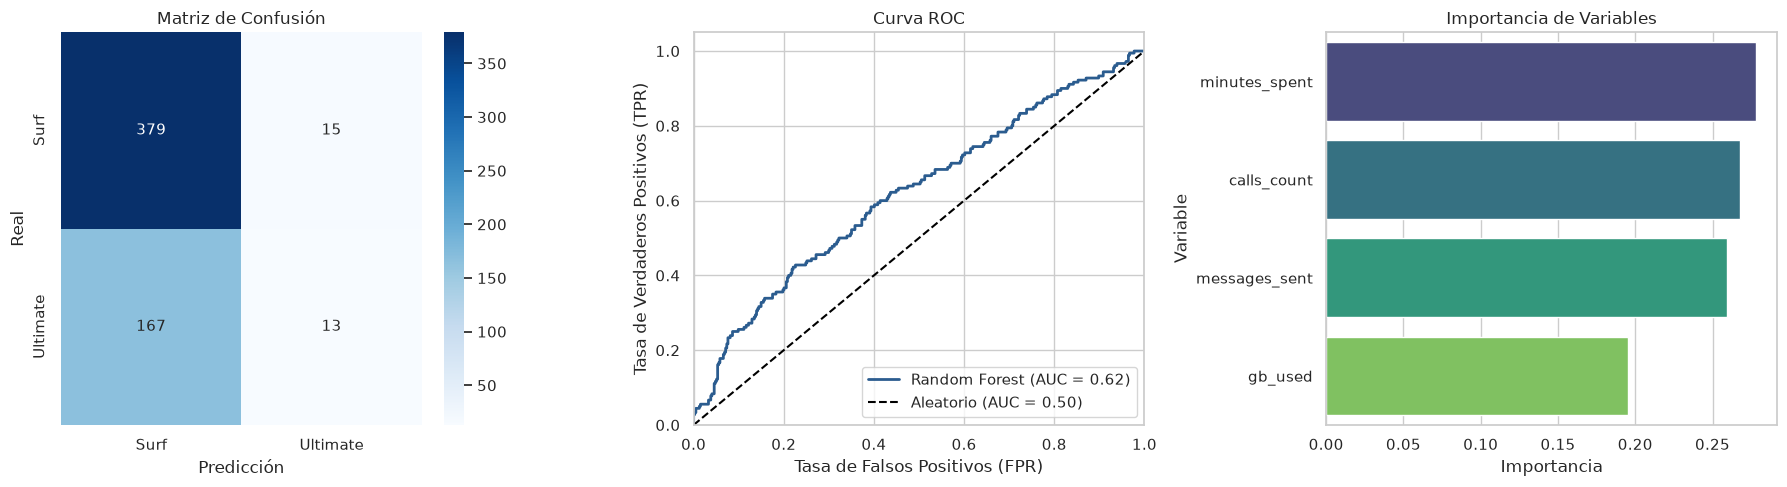

In [176]:
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve

# Selección del modelo con mayor capacidad predictiva
best_model = modelos["Random Forest (Optimizado Accuracy)"]
y_pred_best = best_model.predict(X_test)

# Extracción de probabilidades de la clase positiva (Ultimate)
probs = best_model.predict_proba(X_test)
y_proba_best = probs[:, -1]

print("Reporte de Clasificación del Modelo con Mayor Exactitud:")
print(classification_report(y_test, y_pred_best, target_names=['Surf', 'Ultimate']))

# Creación de panel triple de diagnóstico
fig, (ax_cm, ax_roc, ax_imp) = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))

# 1. Matriz de Confusión
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=['Surf', 'Ultimate'], 
    yticklabels=['Surf', 'Ultimate'], 
    ax=ax_cm
)
ax_cm.set_title('Matriz de Confusión')
ax_cm.set_xlabel('Predicción')
ax_cm.set_ylabel('Real')

# 2. Curva ROC (Trazada con matplotlib estándar para máxima compatibilidad)
fpr, tpr, _ = roc_curve(y_test, y_proba_best)
auc_val = roc_auc_score(y_test, y_proba_best)

ax_roc.plot(fpr, tpr, color='#2b5c8f', lw=2, label=f'Random Forest (AUC = {auc_val:.2f})')
ax_roc.plot((0, 1), (0, 1), color='black', linestyle='--', label='Aleatorio (AUC = 0.50)')
ax_roc.set_xlim((0.0, 1.0))
ax_roc.set_ylim((0.0, 1.05))
ax_roc.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax_roc.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
ax_roc.set_title('Curva ROC')
ax_roc.legend(loc='lower right')

# 3. Importancia de Variables
importances = best_model.feature_importances_
df_imp = pd.DataFrame({'Variable': features, 'Importancia': importances}).sort_values('Importancia', ascending=False)
sns.barplot(
    data=df_imp, 
    x='Importancia', 
    y='Variable', 
    hue='Variable', 
    palette='viridis', 
    legend=False, 
    ax=ax_imp
)
ax_imp.set_title('Importancia de Variables')

plt.tight_layout()
plt.savefig('../reportes/diagnostico_ml_completo.png', dpi=300)
plt.show()

Tasa de Cancelación (Churn) por Tarifa:


,Tarifa,Total Clientes,Clientes Cancelados,Tasa de Churn
0,surf,339,23,0.067847
1,ultimate,161,11,0.068323



Total de clientes en tarifa Surf: 333
Clientes Surf con gasto mensual promedio > $70 USD: 87 (26.1%)


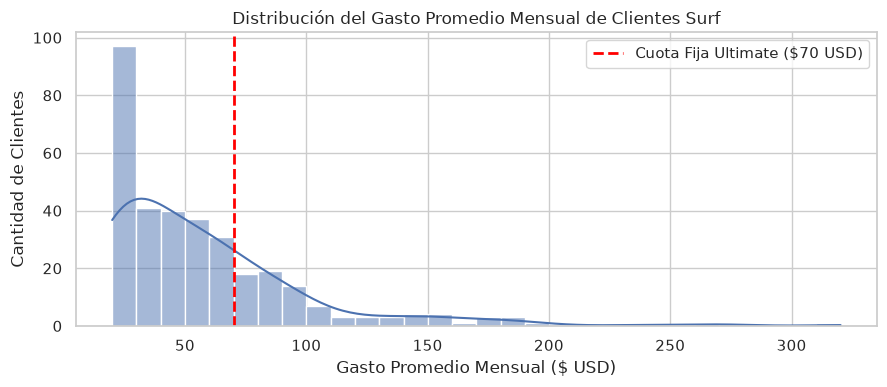

In [177]:
# 1. Análisis de Churn por Tarifa
df_users['is_churn'] = df_users['churn_date'].notna().astype(int)

churn_por_plan = df_users.groupby('plan')['is_churn'].agg(['count', 'sum', 'mean']).reset_index()
churn_por_plan.columns = ['Tarifa', 'Total Clientes', 'Clientes Cancelados', 'Tasa de Churn']
print("Tasa de Cancelación (Churn) por Tarifa:")
display(churn_por_plan)

# 2. Identificación de usuarios Surf que superan los $70 USD mensuales
surf_users_avg = df_monthly[df_monthly['plan'] == 'surf'].groupby('user_id')['total_revenue'].mean()
upsell_candidates = surf_users_avg[surf_users_avg > 70]

print(f"\nTotal de clientes en tarifa Surf: {len(surf_users_avg)}")
print(f"Clientes Surf con gasto mensual promedio > $70 USD: {len(upsell_candidates)} ({len(upsell_candidates)/len(surf_users_avg)*100:.1f}%)")

# 3. Visualización del sobrecosto asumido por estos clientes frente al costo fijo de Ultimate
plt.figure(figsize=(9, 4))
sns.histplot(surf_users_avg, bins=30, color='#4c72b0', kde=True)
plt.axvline(70, color='red', linestyle='--', linewidth=2, label='Cuota Fija Ultimate ($70 USD)')
plt.title('Distribución del Gasto Promedio Mensual de Clientes Surf')
plt.xlabel('Gasto Promedio Mensual ($ USD)')
plt.ylabel('Cantidad de Clientes')
plt.legend()
plt.tight_layout()
plt.savefig('../reportes/distribucion_upselling_surf.png', dpi=300)
plt.show()

## 6. Conclusiones y Recomendaciones Estratégicas

### 1. Dinámica de Ingresos y Rentabilidad por Tarifa
* **Aporte Global al Negocio**: La tarifa **Surf** aporta la mayor cuota de facturación absoluta a la compañía, con **\$95,491.18 USD** frente a los **\$52,066.00 USD** de Ultimate (representando el **64.7% de los ingresos totales** de la muestra analizada).
* **Vulnerabilidad Estructural de Surf**: A pesar de su volumen, el **67.05% de los ingresos de Surf proviene de penalizaciones por sobrecostos** (\$64,031.18 USD), principalmente por tráfico de internet tarificado a \$10/GB adicional. El usuario promedio de Surf abona **\$60.71 USD mensuales**, triplicando la cuota base contratada de \$20 USD.
* **Solidez Financiera de Ultimate**: El **96.80% de los ingresos de Ultimate** corresponde a la cuota fija recurrente (\$70 USD base). Presenta un ingreso promedio significativamente mayor (**ARPU de \$72.31 USD**) y una predictibilidad financiera sustancialmente superior, con una desviación estándar de apenas **\$11.40 USD** (frente a **\$55.39 USD** en Surf).
* **Validación Estadística**: La prueba $t$ de Welch confirmó que el ingreso promedio de Ultimate supera de manera estadísticamente significativa al de Surf ($t = -7.95$, $p = 3.17 \times 10^{-15}$).

### 2. Contraste Geográfico Regional (NY-NJ vs. Otras Regiones)
* **Resultado del Contraste**: Se rechaza la hipótesis nula ($t = -2.13$, $p = 0.0335 < \alpha = 0.05$). El ingreso promedio mensual en la región metropolitana de **NY-NJ (\$59.92 USD)** es estadísticamente inferior al del conjunto de las demás regiones (**\$65.22 USD**).
* **Evaluación de Impacto en Negocio**: Si bien la significancia estadística es verificable debido al tamaño muestral ($n = 2,293$), la brecha monetaria neta es de apenas **\$5.30 USD por usuario** (un efecto práctico reducido). Por consiguiente, **no se aconseja diversificar las tarifas por región geográfica**, ya que los costos operativos de implementar precios regionales superarían el diferencial de ingresos.

### 3. Diagnóstico de Machine Learning y Comportamiento del Usuario
* **La Paradoja de Asignación de Tarifas**: Las medianas de consumo entre clientes de Surf y Ultimate son virtualmente idénticas (**17.0 GB** y **424-425 minutos**). Esto demuestra que los usuarios no eligen su plan a partir de un dimensionamiento racional de su demanda, sino por factores de entrada o costo inicial percibido.
* **Desempeño Predictivo**: Con las 4 variables de tráfico mensuales, los modelos supervisados alcanzan un **Accuracy de ~68.3%** y un **ROC-AUC de 0.62**. Este rendimiento no refleja una deficiencia algorítmica, sino el elevado solapamiento intrínseco de las distribuciones de consumo. El modelo con balanceo de clases (`Random Forest Balanced`) es el preferido para detectar usuarios con propensión a un uso intensivo (F1-score de 0.45 en Ultimate).

### 4. Plan de Acción Comercial y Asignación de Recursos
1. **Campaña de Migración Preventiva (*Upselling Proactivo*)**:
   * Se identificaron **87 usuarios de Surf** cuyo consumo recurrente genera un cobro mensual promedio superior a los **\$70 USD** (llegando a picos de más de \$200 USD).
   * **Riesgo**: Aunque este grupo es altamente lucrativo a corto plazo, la fricción generada por cobros excesivos imprevistos (*bill shock*) es el principal detonante de abandono (*churn*).
   * **Acción**: Contactar a estos 87 clientes con una oferta directa de migración: *"Estabiliza tu factura en \$70 USD fijos con 30 GB incluidos y olvídate de cargos extra"*. Esto fideliza un flujo garantizado de **\$6,090 USD mensuales en ingresos recurrentes predecibles**.
2. **Reasignación del Presupuesto Publicitario**:
   * Se recomienda al departamento de marketing **concentrar la inversión publicitaria en la captación de clientes para la tarifa Ultimate**. 
   * Si bien Surf atrae más usuarios por su bajo costo de entrada (\$20 USD), Ultimate ofrece un mayor valor de vida del cliente (*Customer Lifetime Value - LTV*), un flujo de caja predecible sin riesgo de mora por sobregiros y una experiencia de usuario de menor fricción.